# 5.1.4 Model 4: Support Vector Regression (SVR)

Kernel-based model, a different modelling paradigm from the linear baseline and the two tree ensembles (Random Forest, XGBoost) already covered. Trained on `X_train_scaled.csv` / `X_test_scaled.csv` (log1p-transformed numeric features, per Section 3.11.2) - SVR is a distance/kernel-based method, so unlike Linear Regression it is sensitive to differences in feature *variance*, not just monotonic scale, which log1p alone does not equalise.

An additional `StandardScaler` is therefore needed on top of the log1p-scaled data, same reasoning as `model_knn.ipynb`. As in that notebook, the scaler is wrapped together with the estimator inside a single `sklearn.pipeline.Pipeline` rather than fit once upfront on the whole of `X_train`: this keeps the scaler's mean/std computation properly nested inside every cross-validation fold below - for each fold, the scaler is fit only on that fold's training portion and applied to its validation portion, so no validation row ever influences its own scaling statistics (the same train-only-fit principle Section 3.9-3.11 applies to encoding and imputation, extended one level deeper into CV).

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import make_scorer
from sklearn.inspection import permutation_importance
import joblib
import sys, os
sys.path.append(os.path.dirname(os.path.abspath('__file__')))
from model_utils import evaluate_model, cross_validate_model

# A handful of (C, gamma) combinations near the large-C end of the grid make libsvm's
# SMO solver converge extremely slowly (near-hard-margin optimisation). Capping
# max_iter bounds worst-case fit time; a combination that hits the cap simply scores
# worse in CV and is not selected, so this does not bias the search outcome.
MAX_ITER = 5000
warnings.filterwarnings("ignore", category=ConvergenceWarning)

MODELLING_DIR = os.path.join("..", "data", "modelling")
MODEL_DIR = os.path.join("..", "models")

X_train_log1p = pd.read_csv(os.path.join(MODELLING_DIR, "X_train_scaled.csv"))
X_test_log1p = pd.read_csv(os.path.join(MODELLING_DIR, "X_test_scaled.csv"))
y_train = pd.read_csv(os.path.join(MODELLING_DIR, "y_train.csv"))["price"]
y_test = pd.read_csv(os.path.join(MODELLING_DIR, "y_test.csv"))["price"]

print(f"X_train: {X_train_log1p.shape} | X_test: {X_test_log1p.shape}")

X_train: (3004, 51) | X_test: (751, 51)


## RM-scale CV Scorer
As in the Random Forest, XGBoost, and KNN notebooks, `y_train`/`y_test` are `log(price)` (Section 3.6). A plain `neg_root_mean_squared_error` scorer would rank configurations by log-scale RMSE, which - since `exp()` is non-linear - does not guarantee the same ranking as RM-scale RMSE, this project's primary metric (Section 1.8). `rm_rmse_scorer` below converts predictions back to RM before scoring, so it is used for every CV-based comparison in this notebook.

In [2]:
def rm_scale_rmse(y_true_log, y_pred_log):
    y_true_rm = np.exp(y_true_log)
    y_pred_rm = np.exp(y_pred_log)
    return np.sqrt(np.mean((y_true_rm - y_pred_rm) ** 2))

rm_rmse_scorer = make_scorer(rm_scale_rmse, greater_is_better=False)

# Same fold split used by cross_validate_model() (model_utils.py), so GridSearchCV's
# selection criterion and the final CV report below are directly comparable.
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42)

## Effect of Kernel (Figure 1)
Each kernel is wrapped in `Pipeline([("scaler", StandardScaler()), ("svr", SVR(...))])`, fit on `X_train_log1p`, so the scaler is refit per-fold during the CV below rather than once upfront (see the nesting rationale above). `C` and `epsilon` are fixed at SVR's own defaults (`C=1.0`, `epsilon=0.1`) across all three kernels, so the comparison isolates the kernel choice. `gamma` (rbf/poly) and `degree` (poly) are left at their sklearn defaults (`'scale'` and `3`) since they have no equivalent for the linear kernel. Train RMSE and 5-fold CV RMSE (RM scale) are compared on `X_train_log1p` only; the kernel with the lowest CV RMSE is carried forward into hyperparameter tuning below.

5-fold CV (mean +/- std):
  RMSE:  RM 212,232 +/- 26,710  (60.4% of median price)
  MAE:   RM 114,112 +/- 7,576
  MAPE:  29.4% +/- 1.6%
  R2:    0.5634 +/- 0.1014



5-fold CV (mean +/- std):
  RMSE:  RM 191,860 +/- 39,585  (54.5% of median price)
  MAE:   RM 83,574 +/- 5,980
  MAPE:  19.8% +/- 1.4%
  R2:    0.6552 +/- 0.0712



5-fold CV (mean +/- std):
  RMSE:  RM 225,873 +/- 77,062  (64.2% of median price)
  MAE:   RM 91,309 +/- 8,425
  MAPE:  20.8% +/- 1.4%
  R2:    0.4565 +/- 0.3580



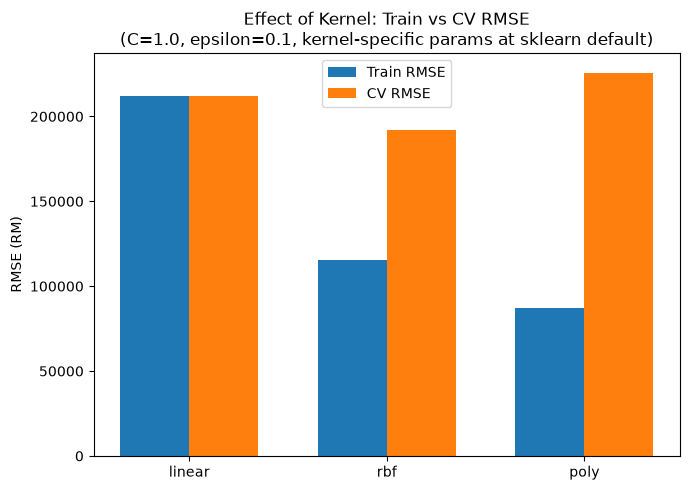

Selected kernel: rbf  (kernel-specific parameter: gamma)
linear: Train RMSE=RM211,745  CV RMSE=RM212,232
rbf: Train RMSE=RM115,542  CV RMSE=RM191,860
poly: Train RMSE=RM87,014  CV RMSE=RM225,873


In [3]:
def make_pipeline(**svr_kwargs):
    return Pipeline([("scaler", StandardScaler()), ("svr", SVR(**svr_kwargs))])


kernels = ["linear", "rbf", "poly"]
kernel_train_rmse = []
kernel_cv_rmse = []

for k in kernels:
    m = make_pipeline(kernel=k, C=1.0, epsilon=0.1, max_iter=MAX_ITER)
    m.fit(X_train_log1p, y_train)
    kernel_train_rmse.append(evaluate_model(m, X_train_log1p, y_train)["RMSE"])
    cv = cross_validate_model(make_pipeline(kernel=k, C=1.0, epsilon=0.1, max_iter=MAX_ITER), X_train_log1p, y_train, n_splits=5)
    kernel_cv_rmse.append(cv["mean"]["RMSE"])
    print()

best_kernel = kernels[int(np.argmin(kernel_cv_rmse))]
# The kernel-specific "shape" parameter searched alongside C and epsilon:
# gamma for rbf, degree for poly, none for linear.
SHAPE_PARAM = {"rbf": "gamma", "poly": "degree", "linear": None}[best_kernel]

x = np.arange(len(kernels))
width = 0.35
plt.figure(figsize=(7, 5))
plt.bar(x - width / 2, kernel_train_rmse, width, label="Train RMSE")
plt.bar(x + width / 2, kernel_cv_rmse, width, label="CV RMSE")
plt.xticks(x, kernels)
plt.ylabel("RMSE (RM)")
plt.title("Effect of Kernel: Train vs CV RMSE\n(C=1.0, epsilon=0.1, kernel-specific params at sklearn default)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Selected kernel: {best_kernel}  (kernel-specific parameter: {SHAPE_PARAM})")
for k, tr, cvr in zip(kernels, kernel_train_rmse, kernel_cv_rmse):
    print(f"{k}: Train RMSE=RM{tr:,.0f}  CV RMSE=RM{cvr:,.0f}")

## Grid Search: Coarse (Figure 2)
`GridSearchCV` searches `C`, `epsilon`, and the kernel-specific parameter (`gamma` for rbf, `degree` for poly) **jointly** with 5-fold CV and the RM-scale scorer. For rbf/poly, the complete three-dimensional search is displayed as one `C` x `gamma`/`degree` heatmap for each tested epsilon; all panels share the same colour scale, and the overall best combination is outlined in red. If the linear kernel wins, its two-dimensional `C` x `epsilon` grid is shown as a single heatmap.

Best params (coarse): {'svr__C': 100, 'svr__epsilon': 0.1, 'svr__gamma': 0.001}
Best CV RMSE (coarse): RM 157,938


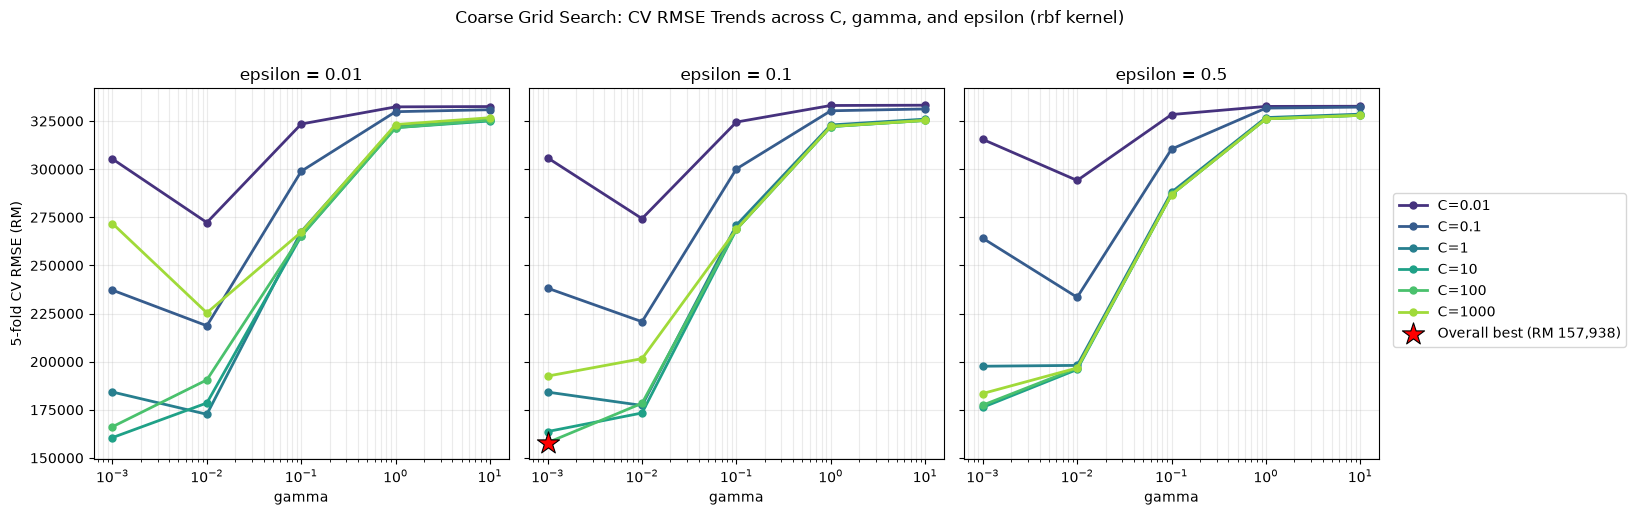

In [4]:
def fine_log_range(center, n=4, span_decades=0.6):
    log_center = np.log10(center)

    return sorted(
        round(value, 6)
        for value in 10 ** np.linspace(
            log_center - span_decades,
            log_center + span_decades,
            n
        )
    )


def plot_grid_trends(grid, second_axis, title):
    """
    Display the complete joint GridSearchCV results as line graphs.

    For RBF or polynomial SVR:
    - each panel represents one epsilon value;
    - each line represents one C value;
    - the horizontal axis represents gamma or degree.

    For linear SVR:
    - each line represents one epsilon value;
    - the horizontal axis represents C.
    """
    results = pd.DataFrame(grid.cv_results_)
    results["cv_rmse"] = -results["mean_test_score"]

    epsilon_values = sorted(
        results["param_svr__epsilon"].astype(float).unique()
    )

    C_values = sorted(
        results["param_svr__C"].astype(float).unique()
    )

    # Linear SVR has no gamma or degree.
    if second_axis == "epsilon":
        plt.figure(figsize=(8, 5))

        colours = sns.color_palette(
            "viridis",
            len(epsilon_values)
        )

        for colour, epsilon in zip(colours, epsilon_values):
            line_data = results[
                np.isclose(
                    results["param_svr__epsilon"].astype(float),
                    epsilon
                )
            ].copy()

            line_data["C_value"] = line_data[
                "param_svr__C"
            ].astype(float)

            line_data = line_data.sort_values("C_value")

            plt.plot(
                line_data["C_value"],
                line_data["cv_rmse"],
                marker="o",
                markersize=6,
                linewidth=2,
                color=colour,
                label=f"epsilon={epsilon:g}"
            )

        plt.scatter(
            float(grid.best_params_["svr__C"]),
            -grid.best_score_,
            marker="*",
            s=280,
            color="red",
            edgecolor="black",
            linewidth=0.8,
            zorder=10,
            label=f"Overall best (RM {-grid.best_score_:,.0f})"
        )

        plt.xscale("log")
        plt.xlabel("C")
        plt.ylabel("5-fold CV RMSE (RM)")
        plt.title(title)
        plt.grid(True, which="both", alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()

        return

    # RBF or polynomial SVR:
    # one panel per epsilon and one line per C.
    colours = sns.color_palette(
        "viridis",
        len(C_values)
    )

    fig, axes = plt.subplots(
        1,
        len(epsilon_values),
        figsize=(5.3 * len(epsilon_values), 5),
        sharex=True,
        sharey=True
    )

    axes = np.atleast_1d(axes)

    for ax, epsilon in zip(axes, epsilon_values):
        epsilon_results = results[
            np.isclose(
                results["param_svr__epsilon"].astype(float),
                epsilon
            )
        ]

        for colour, C in zip(colours, C_values):
            line_data = epsilon_results[
                np.isclose(
                    epsilon_results["param_svr__C"].astype(float),
                    C
                )
            ].copy()

            line_data[second_axis] = line_data[
                f"param_svr__{second_axis}"
            ].astype(float)

            line_data = line_data.sort_values(second_axis)

            ax.plot(
                line_data[second_axis],
                line_data["cv_rmse"],
                marker="o",
                markersize=5,
                linewidth=2,
                color=colour,
                label=f"C={C:g}"
            )

        if second_axis == "gamma":
            ax.set_xscale("log")

        ax.set_title(f"epsilon = {epsilon:g}")
        ax.set_xlabel(second_axis)
        ax.grid(True, which="both", alpha=0.25)

    axes[0].set_ylabel("5-fold CV RMSE (RM)")

    # Mark the best combination across the complete joint search.
    best_epsilon = float(
        grid.best_params_["svr__epsilon"]
    )

    best_axis_index = epsilon_values.index(
        best_epsilon
    )

    best_axis = axes[best_axis_index]

    best_axis.scatter(
        float(
            grid.best_params_[
                f"svr__{second_axis}"
            ]
        ),
        -grid.best_score_,
        marker="*",
        s=280,
        color="red",
        edgecolor="black",
        linewidth=0.8,
        zorder=10,
        label=f"Overall best (RM {-grid.best_score_:,.0f})"
    )

    # Obtain the C lines from the first panel.
    handles, labels = axes[0].get_legend_handles_labels()

    # Add the best-point marker if it is located in another panel.
    if best_axis_index != 0:
        best_handles, best_labels = (
            best_axis.get_legend_handles_labels()
        )

        handles.append(best_handles[-1])
        labels.append(best_labels[-1])

    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(0.875, 0.5),
        frameon=True
    )

    fig.suptitle(
        title,
        y=1.02
    )

    fig.tight_layout(
        rect=[0, 0, 0.88, 1]
    )

    plt.show()


SECOND_AXIS = (
    SHAPE_PARAM
    if SHAPE_PARAM
    else "epsilon"
)

C_COARSE = [
    0.01,
    0.1,
    1,
    10,
    100,
    1000
]

EPSILON_COARSE = [
    0.01,
    0.1,
    0.5
]

if best_kernel == "rbf":
    param_grid_coarse = {
        "svr__C": C_COARSE,
        "svr__gamma": [
            0.001,
            0.01,
            0.1,
            1,
            10
        ],
        "svr__epsilon": EPSILON_COARSE
    }

elif best_kernel == "poly":
    param_grid_coarse = {
        "svr__C": C_COARSE,
        "svr__degree": [
            2,
            3,
            4,
            5
        ],
        "svr__epsilon": EPSILON_COARSE
    }

else:
    param_grid_coarse = {
        "svr__C": C_COARSE,
        "svr__epsilon": EPSILON_COARSE
    }


grid_coarse = GridSearchCV(
    make_pipeline(
        kernel=best_kernel,
        max_iter=MAX_ITER
    ),
    param_grid_coarse,
    scoring=rm_rmse_scorer,
    cv=cv_splitter,
    n_jobs=-1
)

grid_coarse.fit(
    X_train_log1p,
    y_train
)


print(
    "Best params (coarse):",
    grid_coarse.best_params_
)

print(
    f"Best CV RMSE (coarse): "
    f"RM {-grid_coarse.best_score_:,.0f}"
)


plot_grid_trends(
    grid_coarse,
    SECOND_AXIS,
    (
        "Coarse Grid Search: CV RMSE Trends across "
        f"C, {SECOND_AXIS}, and epsilon "
        f"({best_kernel} kernel)"
    )
)

## Grid Search: Fine (Figure 3)
Same joint search over `C` (and `gamma`/`degree`, `epsilon`), narrowed around the coarse winner. Each axis is kept to 3-4 candidates at this stage (vs. up to 6 in the coarse pass) so the joint grid's combination count - and therefore the number of 5-fold CV fits - stays manageable now that `epsilon` is a full search dimension rather than a fixed default. `degree` (poly) is a small, fully-enumerated discrete set already, so it is kept at its immediate neighbourhood rather than further narrowed.

Fine C values: [np.float64(25.118864), np.float64(63.095734), np.float64(158.489319), np.float64(398.107171)]
Fine gamma values: [np.float64(0.000251), np.float64(0.000631), np.float64(0.001585), np.float64(0.003981)]
Fine epsilon values: [np.float64(0.039811), np.float64(0.1), np.float64(0.251189)]
Number of fine-grid combinations: 48



Best parameters (fine): {'svr__C': np.float64(63.095734), 'svr__epsilon': np.float64(0.039811), 'svr__gamma': np.float64(0.001585)}
Best CV RMSE (fine): RM 156,535
Best CV RMSE (coarse): RM 157,938
RMSE improvement: RM 1,403


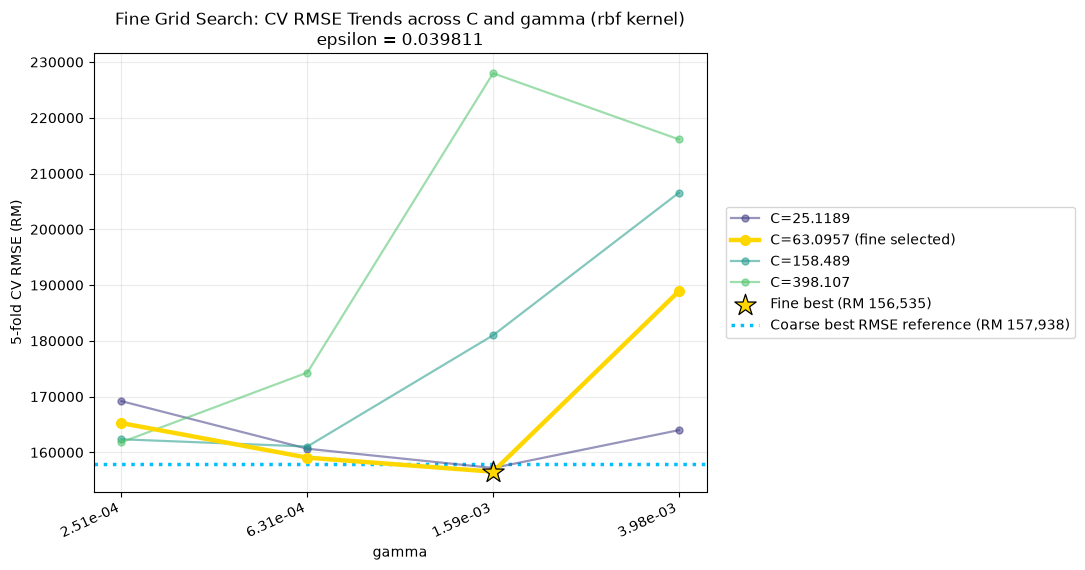

In [5]:
from matplotlib.ticker import NullLocator

# Restore the original fine-range function.
# It generates evenly spaced values around the coarse optimum
# without forcing the coarse value into the fine grid.
def fine_log_range(center, n=4, span_decades=0.6):
    log_c = np.log10(center)
    return sorted(
        round(v, 6)
        for v in 10 ** np.linspace(
            log_c - span_decades,
            log_c + span_decades,
            n
        )
    )


best_coarse = grid_coarse.best_params_

# Generate the original fine-search ranges
C_fine = fine_log_range(
    best_coarse["svr__C"],
    n=4,
    span_decades=0.6
)

epsilon_fine = fine_log_range(
    best_coarse["svr__epsilon"],
    n=3,
    span_decades=0.4
)

if best_kernel == "rbf":
    gamma_fine = fine_log_range(
        best_coarse["svr__gamma"],
        n=4,
        span_decades=0.6
    )

    param_grid_fine = {
        "svr__C": C_fine,
        "svr__gamma": gamma_fine,
        "svr__epsilon": epsilon_fine
    }

elif best_kernel == "poly":
    d = best_coarse["svr__degree"]

    degree_fine = sorted({
        value for value in [d - 1, d, d + 1]
        if value >= 1
    })

    param_grid_fine = {
        "svr__C": C_fine,
        "svr__degree": degree_fine,
        "svr__epsilon": epsilon_fine
    }

else:
    param_grid_fine = {
        "svr__C": C_fine,
        "svr__epsilon": epsilon_fine
    }


# Display the exact fine-search space
print("Fine C values:", C_fine)

if best_kernel == "rbf":
    print("Fine gamma values:", gamma_fine)
elif best_kernel == "poly":
    print("Fine degree values:", degree_fine)

print("Fine epsilon values:", epsilon_fine)

number_of_combinations = np.prod(
    [len(values) for values in param_grid_fine.values()]
)

print("Number of fine-grid combinations:", number_of_combinations)


# Conduct the fine GridSearchCV
grid_fine = GridSearchCV(
    estimator=make_pipeline(
        kernel=best_kernel,
        max_iter=MAX_ITER
    ),
    param_grid=param_grid_fine,
    scoring=rm_rmse_scorer,
    cv=cv_splitter,
    n_jobs=-1
)

grid_fine.fit(X_train_log1p, y_train)


# Summarise the results
coarse_rmse = -grid_coarse.best_score_
fine_rmse = -grid_fine.best_score_
rmse_improvement = coarse_rmse - fine_rmse

print("\nBest parameters (fine):", grid_fine.best_params_)
print(f"Best CV RMSE (fine): RM {fine_rmse:,.0f}")
print(f"Best CV RMSE (coarse): RM {coarse_rmse:,.0f}")
print(f"RMSE improvement: RM {rmse_improvement:,.0f}")


# Prepare the fine-grid results
fine_results = pd.DataFrame(grid_fine.cv_results_)
fine_results["cv_rmse"] = -fine_results["mean_test_score"]

best_fine_C = float(grid_fine.best_params_["svr__C"])
best_fine_epsilon = float(grid_fine.best_params_["svr__epsilon"])


if best_kernel in ["rbf", "poly"]:

    shape_parameter = "gamma" if best_kernel == "rbf" else "degree"
    shape_column = f"param_svr__{shape_parameter}"
    best_fine_shape = float(
        grid_fine.best_params_[f"svr__{shape_parameter}"]
    )

    # Plot only the epsilon panel containing the overall fine-grid optimum
    plot_data = fine_results[
        np.isclose(
            fine_results["param_svr__epsilon"].astype(float),
            best_fine_epsilon
        )
    ].copy()

    plot_data["C_value"] = (
        plot_data["param_svr__C"].astype(float)
    )

    plot_data["shape_value"] = (
        plot_data[shape_column].astype(float)
    )

    plot_data = plot_data.sort_values(
        ["C_value", "shape_value"]
    )

    C_values = sorted(plot_data["C_value"].unique())
    shape_values = sorted(plot_data["shape_value"].unique())

    fig, ax = plt.subplots(figsize=(11, 5.8))

    background_colours = plt.cm.viridis(
        np.linspace(0.18, 0.72, len(C_values))
    )

    for colour, C_value in zip(background_colours, C_values):

        line_data = plot_data[
            np.isclose(plot_data["C_value"], C_value)
        ].sort_values("shape_value")

        is_fine_best = np.isclose(C_value, best_fine_C)

        if is_fine_best:
            line_colour = "#FFD700"   # bright yellow
            line_width = 3.2
            marker_size = 7
            alpha = 1.0
            zorder = 4
            label = f"C={C_value:g} (fine selected)"
        else:
            line_colour = colour
            line_width = 1.6
            marker_size = 5
            alpha = 0.55
            zorder = 2
            label = f"C={C_value:g}"

        ax.plot(
            line_data["shape_value"],
            line_data["cv_rmse"],
            marker="o",
            markersize=marker_size,
            linewidth=line_width,
            color=line_colour,
            alpha=alpha,
            zorder=zorder,
            label=label
        )

    # Mark the best fine-grid combination
    ax.scatter(
        best_fine_shape,
        fine_rmse,
        marker="*",
        s=260,
        color="#FFD700",
        edgecolor="black",
        linewidth=0.9,
        zorder=6,
        label=f"Fine best (RM {fine_rmse:,.0f})"
    )

    # Show the coarse-grid RMSE only as a reference
    ax.axhline(
        y=coarse_rmse,
        color="#00BFFF",
        linestyle=":",
        linewidth=2.5,
        zorder=1,
        label=f"Coarse best RMSE reference (RM {coarse_rmse:,.0f})"
    )

    if shape_parameter == "gamma":
        ax.set_xscale("log")

        # Show only the tested gamma values to prevent overlapping labels
        ax.set_xticks(shape_values)
        ax.set_xticklabels(
            [f"{value:.2e}" for value in shape_values],
            rotation=25,
            ha="right"
        )

        ax.xaxis.set_minor_locator(NullLocator())

    else:
        ax.set_xticks(shape_values)

    ax.set_xlabel(shape_parameter)
    ax.set_ylabel("5-fold CV RMSE (RM)")

    ax.set_title(
        f"Fine Grid Search: CV RMSE Trends across C and "
        f"{shape_parameter} ({best_kernel} kernel)\n"
        f"epsilon = {best_fine_epsilon:g}"
    )

    ax.grid(
        True,
        which="major",
        alpha=0.25
    )

    ax.legend(
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
        frameon=True
    )

    fig.tight_layout()
    plt.show()


else:
    # Linear kernel: plot C against CV RMSE for the selected epsilon
    plot_data = fine_results[
        np.isclose(
            fine_results["param_svr__epsilon"].astype(float),
            best_fine_epsilon
        )
    ].copy()

    plot_data["C_value"] = (
        plot_data["param_svr__C"].astype(float)
    )

    plot_data = plot_data.sort_values("C_value")

    fig, ax = plt.subplots(figsize=(9, 5.5))

    ax.plot(
        plot_data["C_value"],
        plot_data["cv_rmse"],
        marker="o",
        linewidth=2.2,
        color="#FFD700",
        label=f"epsilon={best_fine_epsilon:g}"
    )

    ax.scatter(
        best_fine_C,
        fine_rmse,
        marker="*",
        s=260,
        color="#FFD700",
        edgecolor="black",
        linewidth=0.9,
        zorder=5,
        label=f"Fine best (RM {fine_rmse:,.0f})"
    )

    ax.axhline(
        y=coarse_rmse,
        color="#00BFFF",
        linestyle=":",
        linewidth=2.5,
        label=f"Coarse best RMSE reference (RM {coarse_rmse:,.0f})"
    )

    ax.set_xscale("log")
    ax.set_xlabel("C")
    ax.set_ylabel("5-fold CV RMSE (RM)")
    ax.set_title(
        "Fine Grid Search: CV RMSE across C "
        f"(linear kernel, epsilon={best_fine_epsilon:g})"
    )

    ax.grid(True, which="major", alpha=0.25)

    ax.legend(
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
        frameon=True
    )

    fig.tight_layout()
    plt.show()

## Selected Configuration
`GridSearchCV`'s joint search over `C`, `epsilon`, and the kernel-specific parameter (fine pass, `grid_fine.best_params_`) is the sole basis for selection - it is the only step that actually searched all three dimensions together, with the scaler properly refit inside each CV fold. The three Effect-of-* plots below are diagnostic only: each re-fits the model while sweeping **one** parameter at a time around this already-selected point (the `validation_curve` idea), to show *why* that point is a reasonable choice - they do not themselves alter the selected configuration.

In [6]:
final_params = {"kernel": best_kernel, "max_iter": MAX_ITER,
                 **{k.split("__", 1)[1]: v for k, v in grid_fine.best_params_.items()}}

print("Selected configuration (from joint grid search):")
for k, v in final_params.items():
    if k == "max_iter":
        continue
    print(f"  {k}: {v}")

Selected configuration (from joint grid search):
  kernel: rbf
  C: 63.095734
  epsilon: 0.039811
  gamma: 0.001585


## Effect of C (Figure 4, diagnostic)
`gamma`/`degree` and `epsilon` are held at the selected configuration; only `C` varies, on a log scale wider than the grid searches so the full underfit -> overfit curve is visible. A small `C` under-penalises training error (both curves high and close together - underfitting); as `C` grows, Train RMSE keeps falling while CV RMSE falls then rises, widening the train/CV gap (overfitting). This confirms the grid search's selected `C` sits at (or near) the CV RMSE minimum - it is not used to change it.

5-fold CV (mean +/- std):
  RMSE:  RM 327,738 +/- 39,012  (93.2% of median price)
  MAE:   RM 172,829 +/- 8,609
  MAPE:  46.0% +/- 1.3%
  R2:    -0.0126 +/- 0.0095


5-fold CV (mean +/- std):
  RMSE:  RM 295,975 +/- 40,460  (84.2% of median price)
  MAE:   RM 140,760 +/- 8,507
  MAPE:  34.1% +/- 1.3%
  R2:    0.1771 +/- 0.0363


5-fold CV (mean +/- std):
  RMSE:  RM 227,451 +/- 40,066  (64.7% of median price)
  MAE:   RM 100,499 +/- 7,176
  MAPE:  23.4% +/- 1.5%
  R2:    0.5166 +/- 0.0594


5-fold CV (mean +/- std):
  RMSE:  RM 178,487 +/- 29,837  (50.8% of median price)
  MAE:   RM 87,181 +/- 5,476
  MAPE:  21.1% +/- 1.2%
  R2:    0.6996 +/- 0.0460


5-fold CV (mean +/- std):
  RMSE:  RM 159,721 +/- 17,514  (45.4% of median price)
  MAE:   RM 81,032 +/- 4,132
  MAPE:  19.9% +/- 1.1%
  R2:    0.7548 +/- 0.0432


5-fold CV (mean +/- std):
  RMSE:  RM 156,535 +/- 10,386  (44.5% of median price)
  MAE:   RM 85,306 +/- 3,885
  MAPE:  21.0% +/- 1.3%
  R2:    0.7593 +/- 0.0614


5-fold CV (mean +/- std):
  RMSE:  RM 172,693 +/- 17,453  (49.1% of median price)
  MAE:   RM 91,949 +/- 4,289
  MAPE:  22.4% +/- 1.7%
  R2:    0.7059 +/- 0.0863


5-fold CV (mean +/- std):
  RMSE:  RM 255,937 +/- 64,343  (72.7% of median price)
  MAE:   RM 119,201 +/- 5,253
  MAPE:  28.3% +/- 2.1%
  R2:    0.3828 +/- 0.1894


5-fold CV (mean +/- std):
  RMSE:  RM 306,205 +/- 117,367  (87.0% of median price)
  MAE:   RM 143,667 +/- 19,593
  MAPE:  35.2% +/- 4.1%
  R2:    0.0793 +/- 0.5288


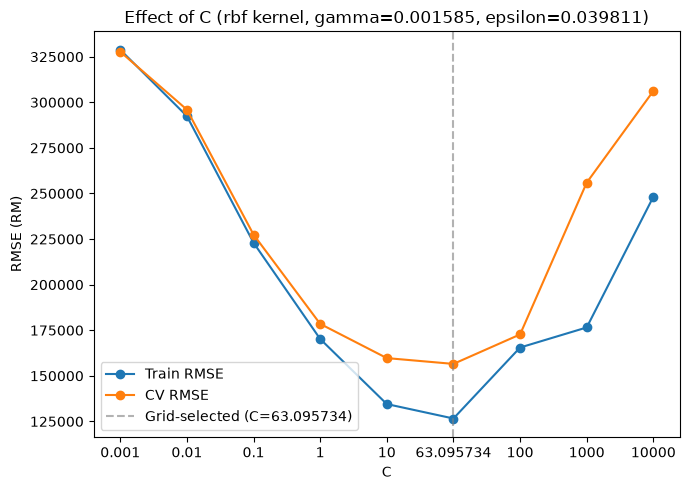

In [7]:
def make_svr_pipeline(C, epsilon, shape_val):
    kwargs = {"kernel": best_kernel, "C": C, "epsilon": epsilon, "max_iter": MAX_ITER}
    if SHAPE_PARAM:
        kwargs[SHAPE_PARAM] = shape_val
    return make_pipeline(**kwargs)


def effect_sweep_values(selected, wide_list):
    return sorted(set(wide_list) | {selected})


C_EFFECT = effect_sweep_values(final_params["C"], [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000])
train_rmse_by_C, cv_rmse_by_C = [], []

for c in C_EFFECT:
    m = make_svr_pipeline(c, final_params["epsilon"], final_params.get(SHAPE_PARAM))
    m.fit(X_train_log1p, y_train)
    train_rmse_by_C.append(evaluate_model(m, X_train_log1p, y_train)["RMSE"])
    cv = cross_validate_model(make_svr_pipeline(c, final_params["epsilon"], final_params.get(SHAPE_PARAM)), X_train_log1p, y_train, n_splits=5)
    cv_rmse_by_C.append(cv["mean"]["RMSE"])

selected_idx = C_EFFECT.index(final_params["C"])

plt.figure(figsize=(7, 5))
plt.plot([str(c) for c in C_EFFECT], train_rmse_by_C, marker="o", label="Train RMSE")
plt.plot([str(c) for c in C_EFFECT], cv_rmse_by_C, marker="o", label="CV RMSE")
plt.axvline(x=selected_idx, color="grey", linestyle="--", alpha=0.6, label=f"Grid-selected (C={final_params['C']})")
plt.xlabel("C")
plt.ylabel("RMSE (RM)")
shape_note = f", {SHAPE_PARAM}={final_params.get(SHAPE_PARAM)}" if SHAPE_PARAM else ""
plt.title(f"Effect of C ({best_kernel} kernel{shape_note}, epsilon={final_params['epsilon']})")
plt.legend()
plt.tight_layout()
plt.show()

## Effect of gamma / degree (Figure 5, diagnostic)
Only meaningful for `rbf` (`gamma`) and `poly` (`degree`) - the linear kernel has neither and this step is skipped for it. `C` and `epsilon` are held at the selected configuration. For `gamma`: small values underfit (decision surface too smooth), larger values progressively overfit (surface bends around individual points). For `degree`: low values underfit (too rigid a polynomial), higher values progressively overfit. As with Figure 4, this confirms the grid search's choice rather than selecting it.

5-fold CV (mean +/- std):
  RMSE:  RM 171,946 +/- 27,610  (48.9% of median price)
  MAE:   RM 87,308 +/- 5,045
  MAPE:  21.5% +/- 1.1%
  R2:    0.7191 +/- 0.0501


5-fold CV (mean +/- std):
  RMSE:  RM 159,608 +/- 8,009  (45.4% of median price)
  MAE:   RM 83,167 +/- 3,075
  MAPE:  20.4% +/- 1.3%
  R2:    0.7524 +/- 0.0489


5-fold CV (mean +/- std):
  RMSE:  RM 156,535 +/- 10,386  (44.5% of median price)
  MAE:   RM 85,306 +/- 3,885
  MAPE:  21.0% +/- 1.3%
  R2:    0.7593 +/- 0.0614


5-fold CV (mean +/- std):
  RMSE:  RM 185,256 +/- 17,598  (52.7% of median price)
  MAE:   RM 93,493 +/- 4,428
  MAPE:  22.9% +/- 1.7%
  R2:    0.6692 +/- 0.0610


5-fold CV (mean +/- std):
  RMSE:  RM 266,298 +/- 46,510  (75.7% of median price)
  MAE:   RM 107,419 +/- 7,881
  MAPE:  25.7% +/- 1.6%
  R2:    0.3362 +/- 0.0859


5-fold CV (mean +/- std):
  RMSE:  RM 321,712 +/- 40,087  (91.5% of median price)
  MAE:   RM 160,948 +/- 8,295
  MAPE:  42.7% +/- 1.4%
  R2:    0.0254 +/- 0.0244


5-fold CV (mean +/- std):
  RMSE:  RM 325,323 +/- 39,592  (92.5% of median price)
  MAE:   RM 165,042 +/- 8,173
  MAPE:  44.1% +/- 1.3%
  R2:    0.0028 +/- 0.0235


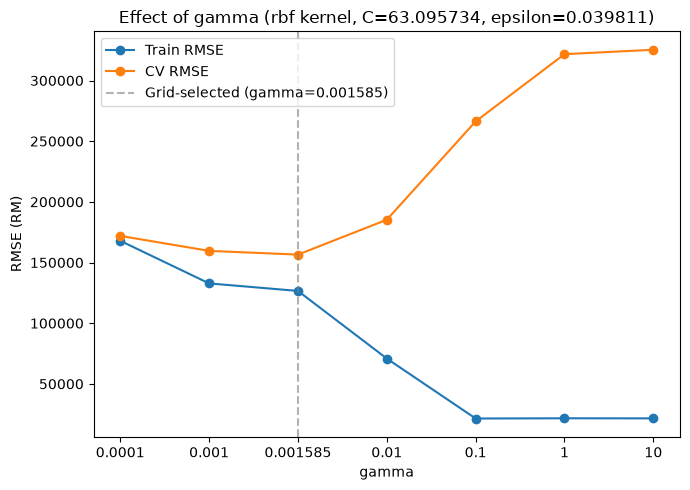

In [8]:
if SHAPE_PARAM == "gamma":
    wide_shape = [0.0001, 0.001, 0.01, 0.1, 1, 10]
elif SHAPE_PARAM == "degree":
    wide_shape = [1, 2, 3, 4, 5, 6]
else:
    wide_shape = None

if wide_shape is not None:
    shape_effect_candidates = effect_sweep_values(final_params[SHAPE_PARAM], wide_shape)
    train_rmse_by_shape, cv_rmse_by_shape = [], []
    for val in shape_effect_candidates:
        m = make_svr_pipeline(final_params["C"], final_params["epsilon"], val)
        m.fit(X_train_log1p, y_train)
        train_rmse_by_shape.append(evaluate_model(m, X_train_log1p, y_train)["RMSE"])
        cv = cross_validate_model(make_svr_pipeline(final_params["C"], final_params["epsilon"], val), X_train_log1p, y_train, n_splits=5)
        cv_rmse_by_shape.append(cv["mean"]["RMSE"])

    selected_idx = shape_effect_candidates.index(final_params[SHAPE_PARAM])

    plt.figure(figsize=(7, 5))
    plt.plot([str(v) for v in shape_effect_candidates], train_rmse_by_shape, marker="o", label="Train RMSE")
    plt.plot([str(v) for v in shape_effect_candidates], cv_rmse_by_shape, marker="o", label="CV RMSE")
    plt.axvline(x=selected_idx, color="grey", linestyle="--", alpha=0.6,
                label=f"Grid-selected ({SHAPE_PARAM}={final_params[SHAPE_PARAM]})")
    plt.xlabel(SHAPE_PARAM)
    plt.ylabel("RMSE (RM)")
    plt.title(f"Effect of {SHAPE_PARAM} ({best_kernel} kernel, C={final_params['C']}, epsilon={final_params['epsilon']})")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Linear kernel has no gamma/degree parameter - skipping this step.")

## Effect of epsilon (Figure 6, diagnostic)
`C` and `gamma`/`degree` are held at the selected configuration; only `epsilon` varies. A small `epsilon` treats more points as prediction errors (pulls the model toward overfitting the noise in `y_train`); a large `epsilon` widens the no-penalty margin, tolerating more deviation and risking underfitting. In practice this parameter tends to move RMSE less than `C` or `gamma`/`degree` do - consistent with it being included in the joint grid search but over a coarser range than the other two.

5-fold CV (mean +/- std):
  RMSE:  RM 169,641 +/- 19,846  (48.2% of median price)
  MAE:   RM 88,526 +/- 5,585
  MAPE:  21.5% +/- 1.7%
  R2:    0.7251 +/- 0.0432


5-fold CV (mean +/- std):
  RMSE:  RM 172,693 +/- 13,256  (49.1% of median price)
  MAE:   RM 89,405 +/- 2,759
  MAPE:  21.5% +/- 1.4%
  R2:    0.7074 +/- 0.0786


5-fold CV (mean +/- std):
  RMSE:  RM 156,535 +/- 10,386  (44.5% of median price)
  MAE:   RM 85,306 +/- 3,885
  MAPE:  21.0% +/- 1.3%
  R2:    0.7593 +/- 0.0614


5-fold CV (mean +/- std):
  RMSE:  RM 167,066 +/- 6,401  (47.5% of median price)
  MAE:   RM 88,306 +/- 2,364
  MAPE:  21.5% +/- 1.3%
  R2:    0.7295 +/- 0.0473


5-fold CV (mean +/- std):
  RMSE:  RM 160,672 +/- 3,786  (45.7% of median price)
  MAE:   RM 85,041 +/- 2,702
  MAPE:  20.7% +/- 1.1%
  R2:    0.7485 +/- 0.0483


5-fold CV (mean +/- std):
  RMSE:  RM 162,271 +/- 9,609  (46.2% of median price)
  MAE:   RM 86,337 +/- 3,448
  MAPE:  20.8% +/- 1.1%
  R2:    0.7471 +/- 0.0315


5-fold CV (mean +/- std):
  RMSE:  RM 178,384 +/- 25,562  (50.7% of median price)
  MAE:   RM 100,113 +/- 6,500
  MAPE:  24.7% +/- 1.3%
  R2:    0.6983 +/- 0.0422
5-fold CV (mean +/- std):
  RMSE:  RM 226,272 +/- 37,307  (64.3% of median price)
  MAE:   RM 118,193 +/- 6,914
  MAPE:  27.7% +/- 1.7%
  R2:    0.5175 +/- 0.0725


5-fold CV (mean +/- std):
  RMSE:  RM 306,018 +/- 39,252  (87.0% of median price)
  MAE:   RM 173,538 +/- 9,747
  MAPE:  54.1% +/- 4.1%
  R2:    0.1180 +/- 0.0388


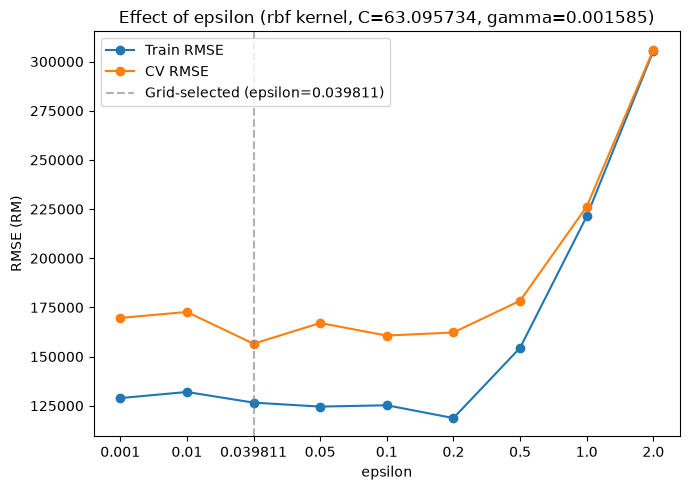

In [9]:
EPSILON_EFFECT = effect_sweep_values(final_params["epsilon"], [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0])
train_rmse_by_eps, cv_rmse_by_eps = [], []

for eps in EPSILON_EFFECT:
    m = make_svr_pipeline(final_params["C"], eps, final_params.get(SHAPE_PARAM))
    m.fit(X_train_log1p, y_train)
    train_rmse_by_eps.append(evaluate_model(m, X_train_log1p, y_train)["RMSE"])
    cv = cross_validate_model(make_svr_pipeline(final_params["C"], eps, final_params.get(SHAPE_PARAM)), X_train_log1p, y_train, n_splits=5)
    cv_rmse_by_eps.append(cv["mean"]["RMSE"])

selected_idx = EPSILON_EFFECT.index(final_params["epsilon"])

plt.figure(figsize=(7, 5))
plt.plot([str(e) for e in EPSILON_EFFECT], train_rmse_by_eps, marker="o", label="Train RMSE")
plt.plot([str(e) for e in EPSILON_EFFECT], cv_rmse_by_eps, marker="o", label="CV RMSE")
plt.axvline(x=selected_idx, color="grey", linestyle="--", alpha=0.6, label=f"Grid-selected (epsilon={final_params['epsilon']})")
plt.xlabel("epsilon")
plt.ylabel("RMSE (RM)")
shape_note = f", {SHAPE_PARAM}={final_params.get(SHAPE_PARAM)}" if SHAPE_PARAM else ""
plt.title(f"Effect of epsilon ({best_kernel} kernel, C={final_params['C']}{shape_note})")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Confirm the difference between the selected epsilon and epsilon=0.01

C_FIXED = final_params["C"]
GAMMA_FIXED = final_params["gamma"]
EPSILON_EXPERIMENT = [final_params["epsilon"], 0.01]

epsilon_experiment = GridSearchCV(
    estimator=make_pipeline(
        kernel=best_kernel,
        max_iter=MAX_ITER
    ),
    param_grid={
        "svr__C": [C_FIXED],
        "svr__gamma": [GAMMA_FIXED],
        "svr__epsilon": EPSILON_EXPERIMENT
    },
    scoring=rm_rmse_scorer,
    cv=cv_splitter,
    n_jobs=-1,
    return_train_score=True
)

epsilon_experiment.fit(
    X_train_log1p,
    y_train
)

epsilon_results = pd.DataFrame(
    epsilon_experiment.cv_results_
)

epsilon_comparison = pd.DataFrame({
    "epsilon": epsilon_results[
        "param_svr__epsilon"
    ].astype(float),

    "CV RMSE (RM)": (
        -epsilon_results["mean_test_score"]
    ),

    "CV RMSE Std (RM)": (
        epsilon_results["std_test_score"]
    ),

    "Rank": (
        epsilon_results["rank_test_score"]
    )
}).sort_values("CV RMSE (RM)")

print(
    f"Fixed parameters: "
    f"C={C_FIXED}, gamma={GAMMA_FIXED}"
)

print("\nEpsilon comparison:")

print(
    epsilon_comparison.to_string(
        index=False,
        formatters={
            "epsilon": lambda value: f"{value:g}",
            "CV RMSE (RM)": lambda value: f"RM {value:,.0f}",
            "CV RMSE Std (RM)": lambda value: f"RM {value:,.0f}"
        }
    )
)

selected_epsilon = final_params["epsilon"]

selected_rmse = epsilon_comparison.loc[
    np.isclose(
        epsilon_comparison["epsilon"],
        selected_epsilon
    ),
    "CV RMSE (RM)"
].iloc[0]

epsilon_001_rmse = epsilon_comparison.loc[
    np.isclose(
        epsilon_comparison["epsilon"],
        0.01
    ),
    "CV RMSE (RM)"
].iloc[0]

difference = epsilon_001_rmse - selected_rmse

print(
    f"\nSelected epsilon: {selected_epsilon:g}"
)

print(
    f"CV RMSE improvement over epsilon=0.01: "
    f"RM {difference:,.0f}"
)

Fixed parameters: C=63.095734, gamma=0.001585

Epsilon comparison:
 epsilon CV RMSE (RM) CV RMSE Std (RM)  Rank
0.039811   RM 156,535        RM 10,386     1
    0.01   RM 172,693        RM 13,256     2

Selected epsilon: 0.039811
CV RMSE improvement over epsilon=0.01: RM 16,158


## Train Final Model
Retrained with `final_params` - the joint grid search's selection, confirmed but not altered by the three diagnostic Effect plots above. Packaged as `Pipeline([("scaler", StandardScaler()), ("svr", SVR(**final_params))])` fit on the complete `X_train_log1p`, same as every Pipeline above and consistent with `model_knn.ipynb` - only the CV-time behaviour involves per-fold refitting; the final model's scaler is fit once on all of `X_train_log1p`, exactly as it would be for any other final fit.

In [11]:
model = make_pipeline(**final_params)
model.fit(X_train_log1p, y_train)
print("Model trained with the selected configuration.")

Model trained with the selected configuration.


## Evaluate
Metrics computed on both train and test sets - the gap between them is needed for Section 6.2's overfitting/underfitting analysis.

In [12]:
train_metrics = evaluate_model(model, X_train_log1p, y_train, label="Train")
print()
test_metrics = evaluate_model(model, X_test_log1p, y_test, label="Test")

Train RMSE:  RM 126,590  (36.2% of median price)
Train MAE:   RM 67,158
Train MAPE:  16.3%
Train R2:    0.8509

Test RMSE:  RM 182,476  (50.7% of median price)
Test MAE:   RM 88,207
Test MAPE:  18.8%
Test R2:    0.6975


## 5-fold Cross-Validation
Run on `X_train_log1p` only (`X_test_log1p` stays untouched) using the selected configuration, for a more robust performance estimate than the single train/test split above, per Section 5.2's cross-validation requirement. `cross_validate_model` clones the Pipeline for each fold, so the scaler is re-fit per fold here too - the hyperparameters are fixed at this point (no further tuning), only the metric breakdown is new.

In [13]:
cv_results = cross_validate_model(make_pipeline(**final_params), X_train_log1p, y_train, n_splits=5)

5-fold CV (mean +/- std):
  RMSE:  RM 156,535 +/- 10,386  (44.5% of median price)
  MAE:   RM 85,306 +/- 3,885
  MAPE:  21.0% +/- 1.3%
  R2:    0.7593 +/- 0.0614


## Sanity Check: Permutation Importance vs EDA (Section 4.5.2)
SVR only exposes `coef_` for the linear kernel - `rbf`/`poly` have none (unlike the linear model's coefficients or the tree ensembles' impurity-based importances) - so permutation importance is used here for consistency regardless of which kernel was selected: each feature is shuffled and the resulting drop in test R2 is measured. Section 4.5.2 ranked Property Size, Bathroom, Parking Lot, and the Has_Gymnasium/Has_Swimming_Pool amenities as the strongest numerical correlates of price - this checks whether SVR's learned importances broadly agree.

In [14]:
perm_result = permutation_importance(
    model, X_test_log1p, y_test, scoring="r2", n_repeats=10, random_state=42, n_jobs=-1,
)
importance_table = pd.Series(perm_result.importances_mean, index=X_test_log1p.columns).sort_values(ascending=False)
print("Top 15 features by permutation importance (mean R2 drop):")
print(importance_table.head(15))

Top 15 features by permutation importance (mean R2 drop):
Property Size                     0.479034
State_Penang                      0.123010
PropertyType_Service_Residence    0.053921
PropertyType_Condominium          0.042645
State_Sabah                       0.041028
Bedroom                           0.034298
Bathroom                          0.029342
State_Kuala_Lumpur                0.028110
Property_Age_Missing              0.025431
PropertyType_Flat                 0.022388
Has_Barbeque_Area                 0.015947
Property Age                      0.015770
Parking Lot                       0.014523
State_Unknown                     0.013868
Has_School                        0.012456
dtype: float64


## Predicted vs Actual (Figure 7)
Final diagnostic scatter on the held-out test set, converted back to RM scale.

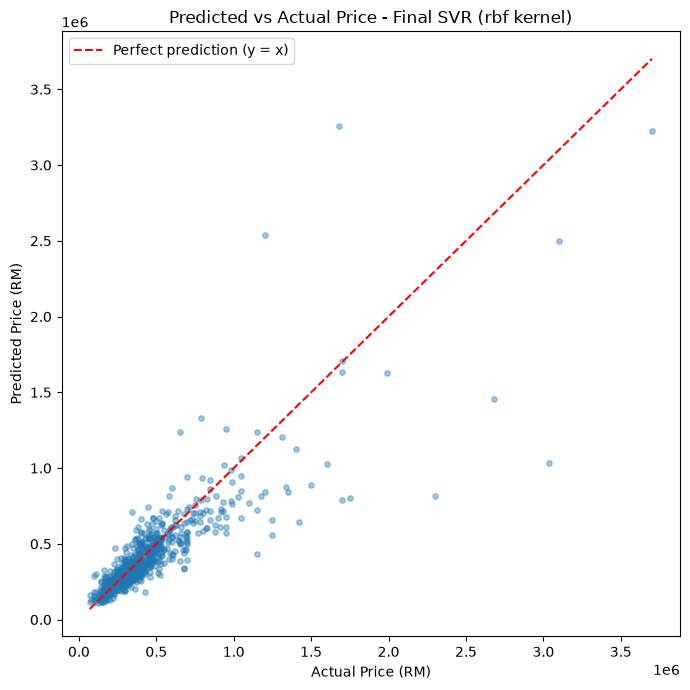

In [15]:
y_test_rm = np.exp(y_test)
y_pred_rm = np.exp(model.predict(X_test_log1p))

plt.figure(figsize=(7, 7))
plt.scatter(y_test_rm, y_pred_rm, alpha=0.4, s=15)
lims = [min(y_test_rm.min(), y_pred_rm.min()), max(y_test_rm.max(), y_pred_rm.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction (y = x)")
plt.xlabel("Actual Price (RM)")
plt.ylabel("Predicted Price (RM)")
plt.title(f"Predicted vs Actual Price - Final SVR ({best_kernel} kernel)")
plt.legend()
plt.tight_layout()
plt.show()

## Save Trained Model
`model` is the full Pipeline (StandardScaler + SVR), so this single file is enough for the Streamlit prototype (Section 8) to load and predict directly, without retraining or managing a separate scaler file.

In [16]:
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)
model_path = os.path.join(MODEL_DIR, "svr_model.pkl")
joblib.dump(model, model_path)
print(f"Model saved to {model_path}")

Model saved to ..\models\svr_model.pkl


## BayesSearchCV Comparison (Exploratory)
This section is exploratory only - it compares the grid search above against `skopt.BayesSearchCV` (Bayesian hyperparameter optimisation) to see whether a smarter search strategy finds anything better. It does **not** change `final_params`, `model`, or the saved `.pkl`.

Where `GridSearchCV` exhaustively evaluates every point on a fixed candidate list, `BayesSearchCV` fits a probabilistic surrogate model (a Gaussian process) over the CV score as a function of the hyperparameters and adaptively picks each next point to evaluate where that surrogate expects the biggest improvement. This lets it search **continuous** ranges (not a fixed list of candidates) under a fixed evaluation budget (`n_iter`) rather than a combinatorial grid size.

Same `Pipeline`, same `cv_splitter` (5-fold, `random_state=42`), same `rm_rmse_scorer`, same joint `C`/`epsilon`/kernel-specific-parameter space as the grid search - only the search *strategy* differs, and the search space is continuous (log-uniform) instead of the grid's fixed candidate lists.

In [17]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer

if SHAPE_PARAM == "gamma":
    bayes_shape_space = {"svr__gamma": Real(1e-3, 10, prior="log-uniform")}
elif SHAPE_PARAM == "degree":
    bayes_shape_space = {"svr__degree": Integer(2, 5)}
else:
    bayes_shape_space = {}

bayes_search_space = {
    "svr__C": Real(1e-2, 1e3, prior="log-uniform"),
    "svr__epsilon": Real(1e-3, 0.5, prior="log-uniform"),
    **bayes_shape_space,
}

bayes_search = BayesSearchCV(
    make_pipeline(kernel=best_kernel, max_iter=MAX_ITER),
    bayes_search_space,
    n_iter=100,
    cv=cv_splitter,
    scoring=rm_rmse_scorer,
    random_state=42,
    n_jobs=-1,
)
bayes_search.fit(X_train_log1p, y_train)

print("Best params (BayesSearchCV):", dict(bayes_search.best_params_))
print(f"Best CV RMSE (BayesSearchCV): RM {-bayes_search.best_score_:,.0f}")
print(f"Best CV RMSE (grid search, for comparison): RM {-grid_fine.best_score_:,.0f}")
diff = -bayes_search.best_score_ - (-grid_fine.best_score_)
print(f"Difference (BayesSearchCV - grid): RM {diff:,.0f}")

Best params (BayesSearchCV): {'svr__C': 17.136504885535444, 'svr__epsilon': 0.001, 'svr__gamma': 0.0016801272560915972}
Best CV RMSE (BayesSearchCV): RM 153,954
Best CV RMSE (grid search, for comparison): RM 156,535
Difference (BayesSearchCV - grid): RM -2,581


### Convergence
Best CV RMSE found so far at each `BayesSearchCV` iteration, against the grid search's result as a reference line. If the curve flattens out at/above the grid search line, the grid already found (about) as good a configuration; if it drops clearly below, Bayesian optimisation found a better point than the grid did.

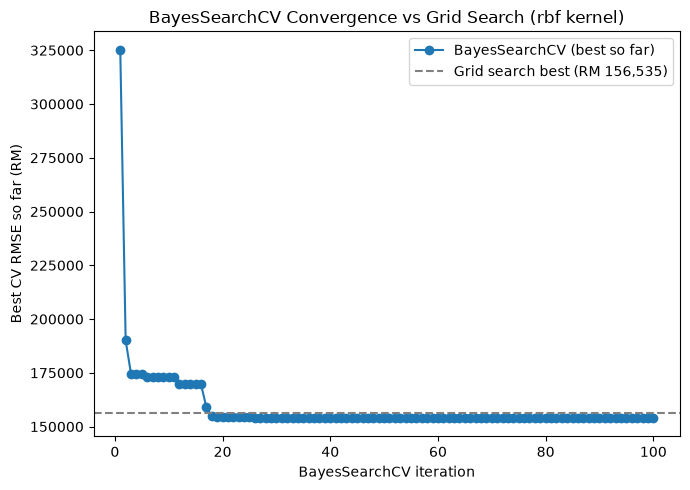

In [18]:
bayes_scores = -np.array(bayes_search.cv_results_["mean_test_score"])
best_so_far = np.minimum.accumulate(bayes_scores)

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(best_so_far) + 1), best_so_far, marker="o", label="BayesSearchCV (best so far)")
plt.axhline(-grid_fine.best_score_, color="grey", linestyle="--",
            label=f"Grid search best (RM {-grid_fine.best_score_:,.0f})")
plt.xlabel("BayesSearchCV iteration")
plt.ylabel("Best CV RMSE so far (RM)")
plt.title(f"BayesSearchCV Convergence vs Grid Search ({best_kernel} kernel)")
plt.legend()
plt.tight_layout()
plt.show()